Лабораторная работа №1

Рокотянский Александр

М8О-202СВ-25

In [ ]:
%pip install pandas numpy scipy matplotlib statsmodels PyWavelets

# Либы

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from scipy import signal, stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

## EDA

In [ ]:
path = 'data/retail_sales_mock_data.csv'
df = pd.read_csv(path, parse_dates=['Date'])
df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


Посмотрим сколько у нас записей, пропусков и повторов дат

In [ ]:
print('Размер', df.shape)
print('\nПропуски')
print(df.isna().sum())
print('\nПовторы дат', df['Date'].duplicated().sum())


df = df.set_index('Date').sort_index()

dates = pd.date_range(df.index.min(), df.index.max(), freq='MS')

print('Пропущенные месяцы', len(dates.difference(df.index)))

df = df.asfreq('MS')

Размер (48, 4)

Пропуски
Date            0
SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

Повторы дат 0
Пропущенные месяцы 0


Всего 48 месяцев и пропусков нет нигде. Первые 2 года будут train, 2022 val и 2023 test

In [ ]:
train = df.iloc[:24].copy()
val = df.iloc[24:36].copy()
test = df.iloc[36:].copy()

y_train = train['SalesAmount']
y_val = val['SalesAmount']
y_test = test['SalesAmount']

print('Train', train.shape)
print('Val', val.shape)
print('Test', test.shape)

train.describe()

Train (24, 3)
Val (12, 3)
Test (12, 3)


,SalesAmount,Promotion,HolidayMonth
count,24.000000,24.000000,24.000000
mean,11255.125000,0.166667,0.083333
std,2039.166482,0.380693,0.282330
min,7783.000000,0.000000,0.000000
25%,9929.250000,0.000000,0.000000
50%,10885.500000,0.000000,0.000000
75%,12722.500000,0.000000,0.000000
max,14696.000000,1.000000,1.000000


### Продажи и акции

Чекнем продажи и найдем месяцы с акциями

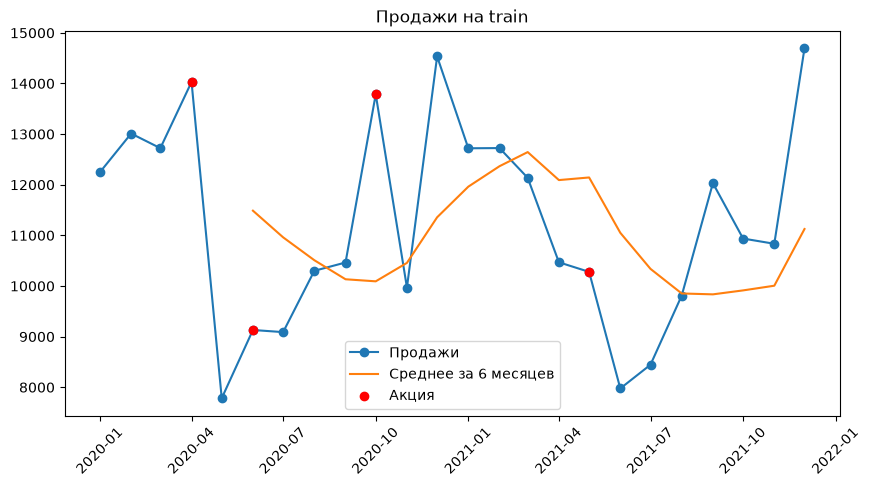

In [ ]:
promo = train['Promotion'] == 1

plt.figure(figsize=(10, 5))
plt.plot(y_train.index, y_train, marker='o', label='Продажи')
plt.plot(y_train.rolling(6).mean(), label='Среднее за 6 месяцев')
plt.scatter(y_train.index[promo], y_train[promo], color='red', label='Акция', zorder=3)
plt.title('Продажи на train')
plt.legend()
plt.xticks(rotation=45)
plt.show()

В апреле и октябре 2020 всплески совпали с акциями

Наложим годы друг на друга

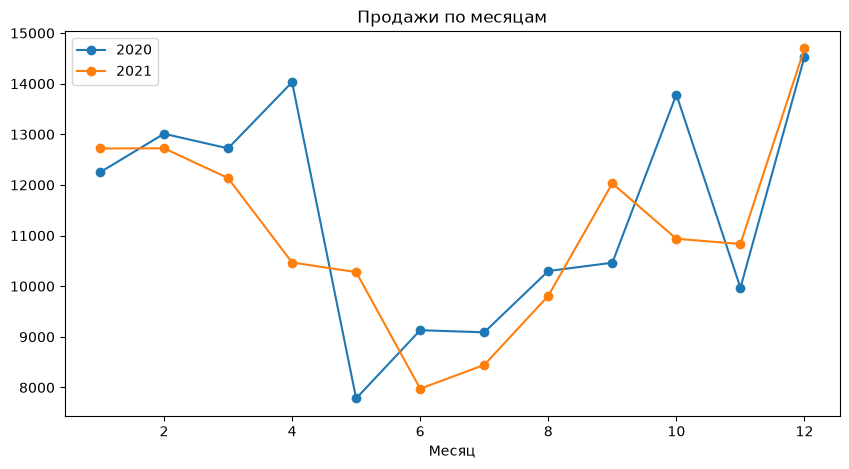

In [ ]:
plt.figure(figsize=(10, 5))
for year, group in y_train.groupby(y_train.index.year):
    plt.plot(group.index.month, group, marker='o', label=str(year))

plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.legend()
plt.show()

Зимой продажи выше, летом спад. Годовой цикл похож +-, хотя некоторые месяцы отличаются

Чекнем распределение и сравним месяцы с акциями и без

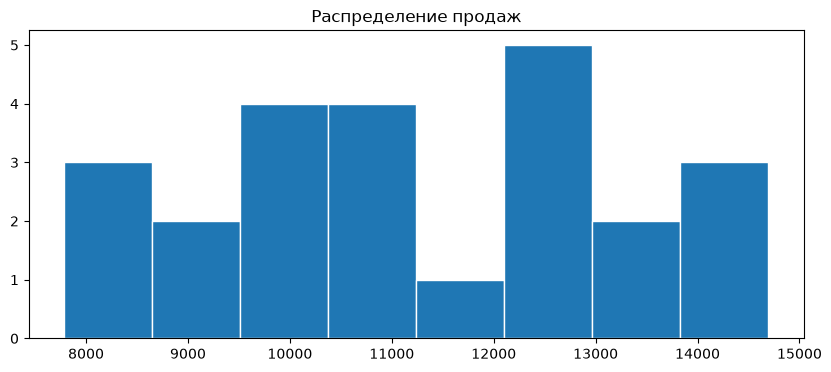

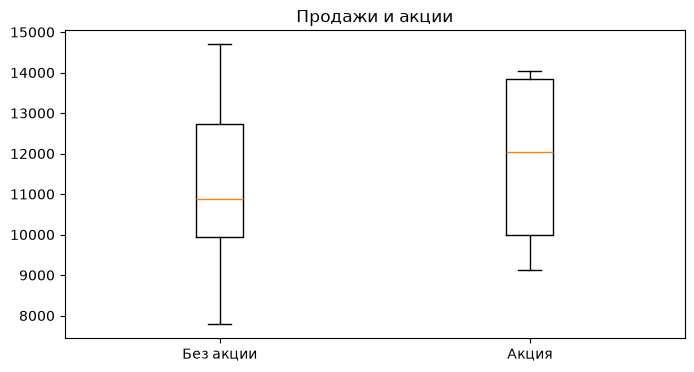

,count,mean,std
Promotion,,,
0,20,11144.85,1997.701318
1,4,11806.50,2473.454332


In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(y_train, bins=8, edgecolor='white')
plt.title('Распределение продаж')
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot([y_train[~promo], y_train[promo]], tick_labels=['Без акции', 'Акция'])
plt.title('Продажи и акции')
plt.show()

train.groupby('Promotion')['SalesAmount'].agg(['count', 'mean', 'std'])

С акциями среднее выше, но их всего четыре и месяцы разные

### ACF и PACF

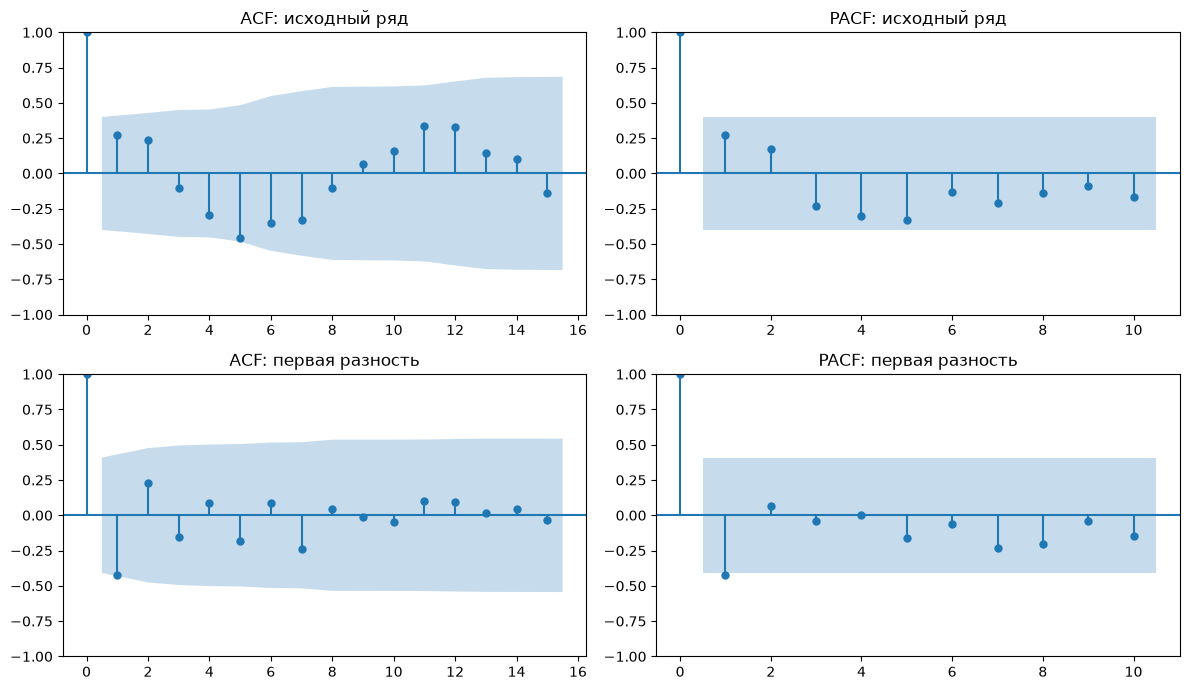

In [ ]:
# смотрим на исходный ряд и разность, чтобы прикинуть порядки AR/MA
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row, series in enumerate([y_train, y_train.diff().dropna()]):
    plot_acf(series, lags=15, ax=axes[row, 0])

    plot_pacf(series, lags=10, method='ywm', ax=axes[row, 1])

    axes[row, 0].set_title(['ACF: исходный ряд', 'ACF: первая разность'][row])

    axes[row, 1].set_title(['PACF: исходный ряд', 'PACF: первая разность'][row])

plt.tight_layout()
plt.show()

По исходному ряду ничего явно не выделяется, все внутри границ

После разности выделился первый лаг. Проверю AR(1) и MA(1). Но все это не выглядит так что нужна разность

### Стационарность

In [ ]:
# сравнить исходный ряд, обычную разность и сезонную
series_list = [
    ('Уровень', y_train),
    ('Разность 1', y_train.diff().dropna()),
    ('Разность 12', y_train.diff(12).dropna())
]

stationarity_rows = []

for name, series in series_list:
    adf = adfuller(
        series,
        maxlag=min(4, len(series) // 2 - 2),
        autolag='AIC',
        result_object=False
    )
    kp = kpss(series, regression='c', nlags='auto', result_object=False)

    stationarity_rows.append({
        'Ряд': name,
        'n': len(series),
        'ADF p': adf[1],
        'KPSS p': kp[1]
    })

stationarity = pd.DataFrame(stationarity_rows)
print(stationarity)

           Ряд   n         ADF p    KPSS p
0      Уровень  24  3.590476e-02  0.100000
1   Разность 1  23  8.333906e-10  0.100000
2  Разность 12  12  4.006437e-03  0.041667


/var/folders/18/q8w628gj0xn4bd2bjb2cv7n852x3hr/T/ipykernel_23503/2502434522.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(series, regression='c', nlags='auto', result_object=False)
/var/folders/18/q8w628gj0xn4bd2bjb2cv7n852x3hr/T/ipykernel_23503/2502434522.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp = kpss(series, regression='c', nlags='auto', result_object=False)


По обоим тестам вроде можно обойтись без обычной разности. KPSS вернул 0.1, но это максимум в его таблице, настоящее p-value выше

После разности со сдвигом 12 тесты показали разное. Там осталось всего 12 месяцев, поэтому проверю варианты с разностями и без. Сезонность будет 12 месяцев вместе с акциями

## Тренд и сезонность

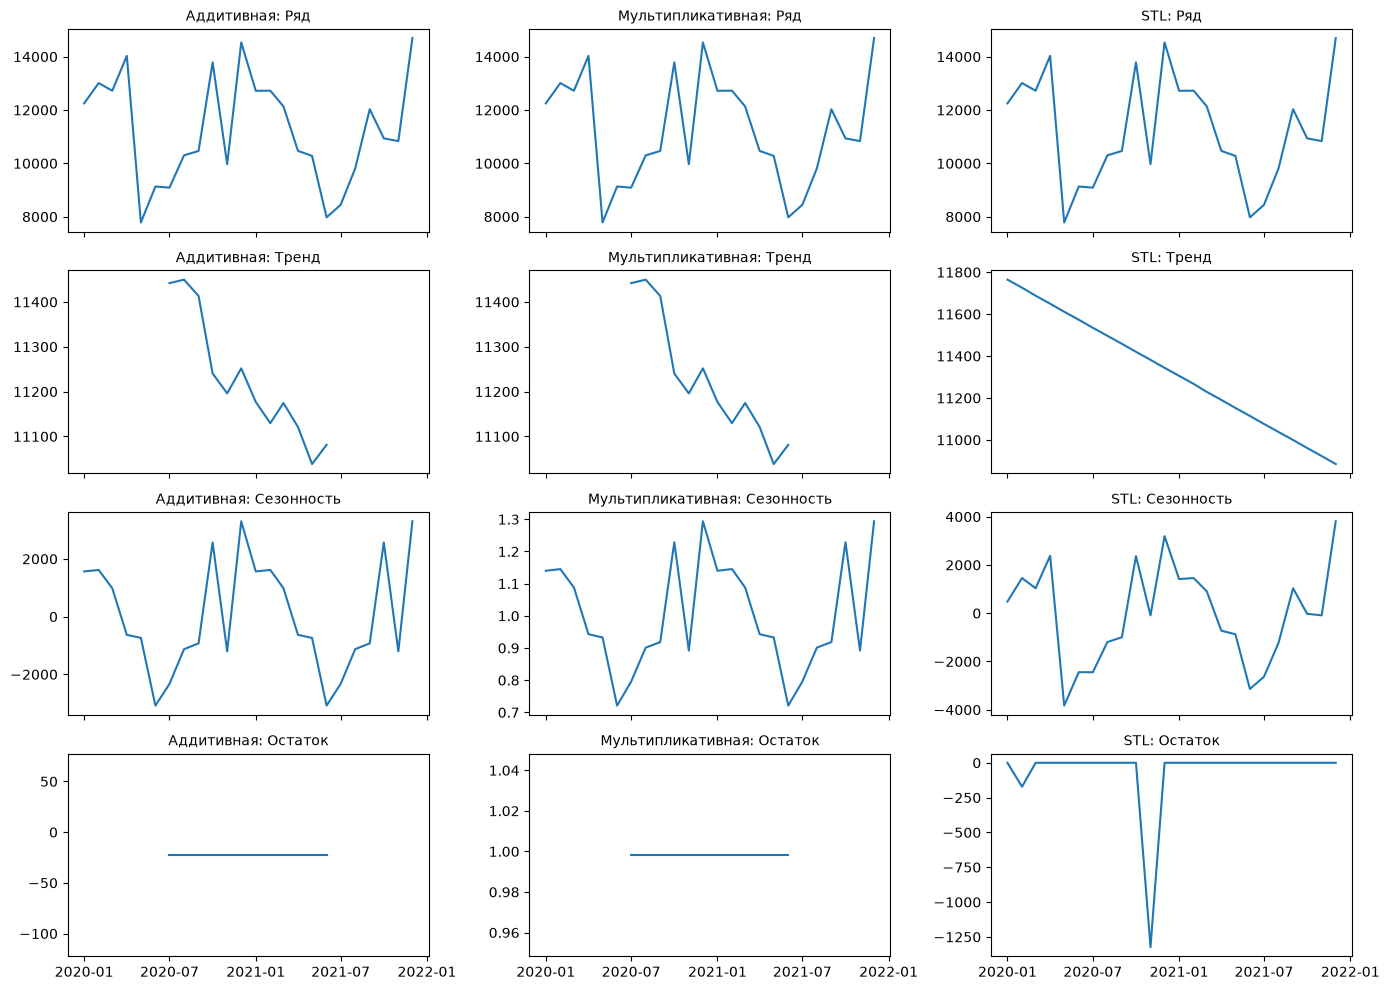

In [ ]:
# У всех разложений один период, 12 месяцев
y = y_train

decompositions = {
    'Аддитивная': seasonal_decompose(y, model='additive', period=12),
    'Мультипликативная': seasonal_decompose(y, model='multiplicative', period=12),
    'STL': STL(y, period=12, robust=True).fit(),
}

component_names = [('observed', 'Ряд'), ('trend', 'Тренд'),
                   ('seasonal', 'Сезонность'), ('resid', 'Остаток')]

fig, axes = plt.subplots(4, 3, figsize=(14, 10), sharex=True)

for col, (name, result) in enumerate(decompositions.items()):
    for row, (attribute, label) in enumerate(component_names):
        values = y if attribute == 'observed' else getattr(result, attribute)
        ax = axes[row, col]
        ax.plot(y.index, values)
        ax.set_title(f'{name}: {label}', fontsize=10)
        ax.ticklabel_format(axis='y', style='plain', useOffset=False)
        finite = np.asarray(values)[np.isfinite(values)]
        if attribute == 'resid' and np.ptp(finite) < 1e-6:
            margin = 0.05 if name == 'Мультипликативная' else 100
            ax.set_ylim(finite.mean() - margin, finite.mean() + margin)

for ax in axes[-1]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

У аддитивного и мультипликативного разложения на краях не хватает данных для расчёта тренда

После разложения остатки почти не меняются. Для оценки сезонности осталось всего по одному значению на каждый месяц.

У STL всего два года данных, маловато...

### FFT

In [ ]:
# уберу тренд, чтобы он не мешал смотреть сезонность в спектре
values = y.to_numpy(dtype=float)
detrended = signal.detrend(values)
fft_trend = values - detrended
frequencies = np.fft.rfftfreq(len(values))
spectrum = np.fft.rfft(detrended)
power = abs(spectrum) ** 2

fft_table = pd.DataFrame({
    'Частота': frequencies[1:],
    'Период, месяцев': 1 / frequencies[1:],
    'Мощность': power[1:]
})
fft_table = fft_table.sort_values('Мощность', ascending=False)
fft_table.head()

,Частота,"Период, месяцев",Мощность
1,0.083333,12.000000,6.525745e+08
11,0.500000,2.000000,1.675474e+08
10,0.458333,2.181818,8.454091e+07
6,0.291667,3.428571,7.474342e+07
7,0.333333,3.000000,6.796348e+07


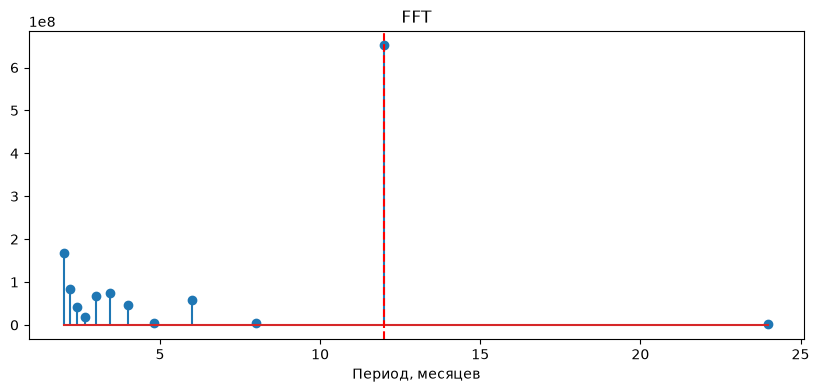

In [ ]:
plt.figure(figsize=(10, 4))
plt.stem(1 / frequencies[1:], power[1:])
plt.axvline(12, color='red', linestyle='--')
plt.xlabel('Период, месяцев')
plt.title('FFT')
plt.show()

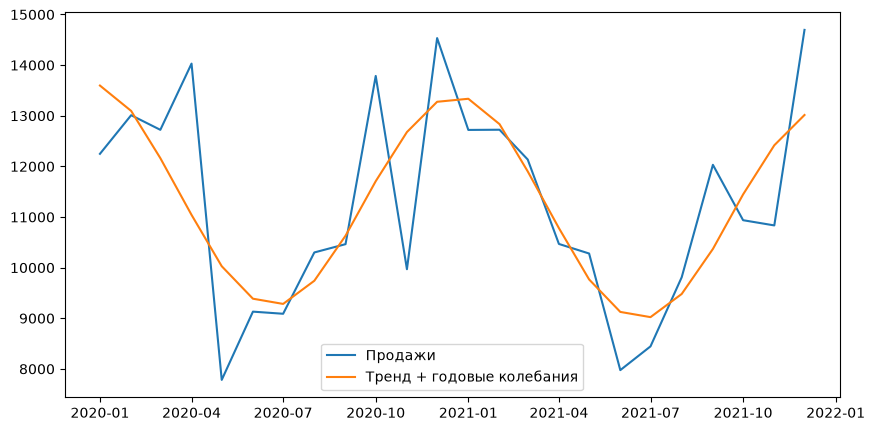

In [ ]:
# выделю колебания продаж с периодом 12 месяцев
annual_spectrum = np.zeros_like(spectrum)
annual_index = np.argmin(abs(frequencies - 1 / 12))
annual_spectrum[annual_index] = spectrum[annual_index]
annual_component = np.fft.irfft(annual_spectrum, n=len(values))
fft_residual = values - fft_trend - annual_component

plt.figure(figsize=(10, 5))
plt.plot(y.index, y, label='Продажи')
plt.plot(y.index, fft_trend + annual_component, label='Тренд + годовые колебания')
plt.legend()
plt.show()

Общие подъёмы и спады вроде видно, а всплески во время акций и в декабре пока непонтяно

Посмотрю на тренд, годовые колебания и остаток отдельно

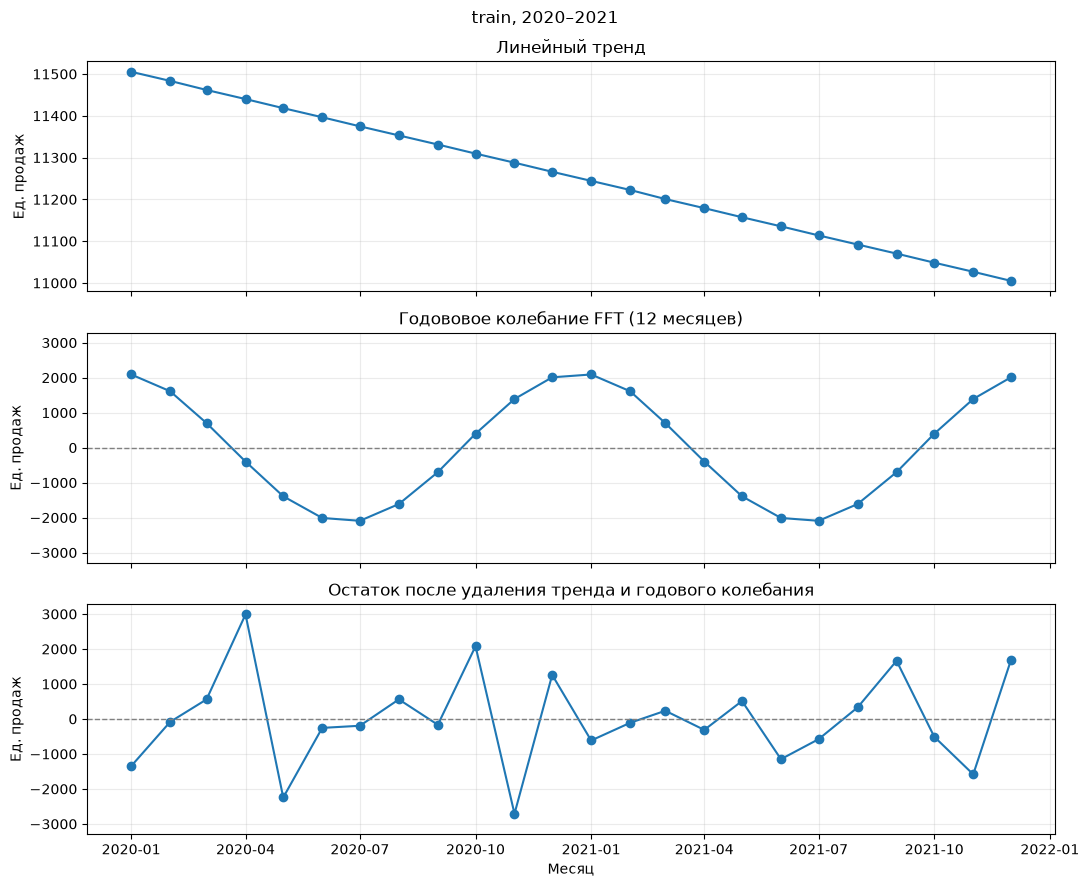

In [ ]:
parts = {
    'Линейный тренд': fft_trend,
    'Годововое колебание FFT (12 месяцев)': annual_component,
    'Остаток после удаления тренда и годового колебания': fft_residual
}

limit = 1.1 * max(np.max(abs(annual_component)), np.max(abs(fft_residual)))

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for i, (name, part) in enumerate(parts.items()):
    ax = axes[i]
    ax.plot(y.index, part, marker='o', color='tab:blue')
    ax.set_title(name)
    ax.set_ylabel('Ед. продаж')
    ax.grid(alpha=0.25)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    if i > 0:
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_ylim(-limit, limit)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].set_xlabel('Месяц')

fig.suptitle('train, 2020–2021')
plt.tight_layout()
plt.show()

Теперь сложим всё обратно

In [ ]:
restored = fft_trend + annual_component + fft_residual

print('Максимальная ошибка восстановления', np.max(abs(restored - values)))

np.testing.assert_allclose(restored, values, rtol=1e-10, atol=1e-8)

Максимальная ошибка восстановления 0.0


В остатке осталось то что не поймали тренд и годовые колебания

Сложили все части обратно и получили исходные продажи

Разница в основном токо из за округления чисел

### Морле

Заюзаем Морле чтобы увидеть частоты во времени

Область влияния краёв будет штрихами

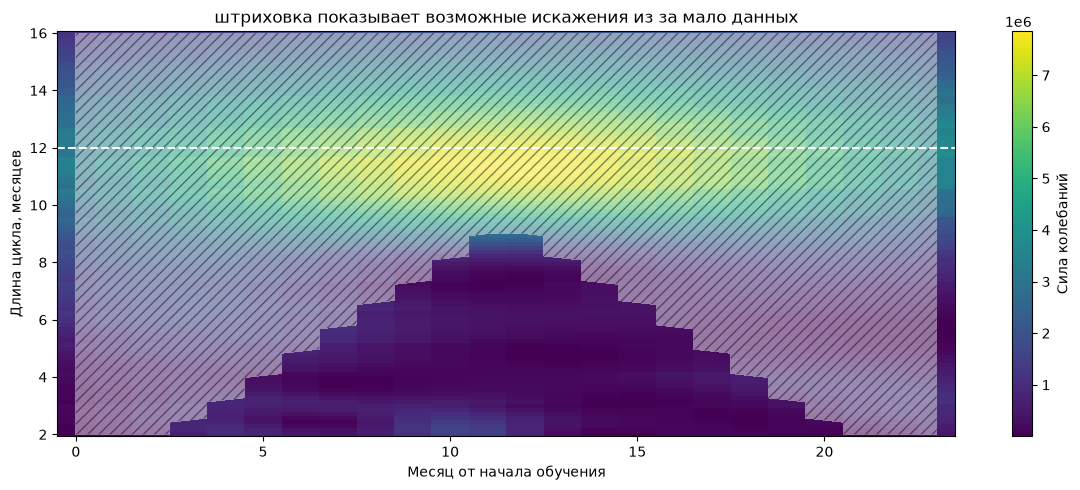

In [ ]:
wavelet = 'cmor1.5-1.0'

periods = np.linspace(2, 16, 100)

scales = pywt.frequency2scale(wavelet, 1 / periods)

coefficients, wave_frequencies = pywt.cwt(detrended, scales, wavelet)

wave_power = abs(coefficients) ** 2

# у начала и конца ряда нехватает соседних данных
# Отметим эти места штриховкой. граница как sqrt(1.5) * scale для этого вейвлета

distance_to_edge = np.minimum(np.arange(len(y)), np.arange(len(y))[::-1])
reliable = distance_to_edge[None, :] >= np.sqrt(1.5) * scales[:, None]

fig, ax = plt.subplots(figsize=(12, 5))

mesh = ax.pcolormesh(np.arange(len(y)), 1 / wave_frequencies, wave_power, shading='auto')

ax.contourf(np.arange(len(y)), 1 / wave_frequencies, (~reliable).astype(int), levels=[0.5, 1.5], colors=['white'], alpha=0.45, hatches=['///'])

ax.axhline(12, color='white', ls='--')

ax.set(
    xlabel='Месяц от начала обучения',
    ylabel='Длина цикла, месяцев',
    title='штриховка показывает возможные искажения из за мало данных'
)

fig.colorbar(mesh, ax=ax, label='Сила колебаний')

plt.tight_layout()
plt.show()

In [ ]:
print('Месяцев без штриховки для периода 12 месяцев',reliable[np.argmin(abs(periods - 12))].sum())

Месяцев без штриховки для периода 12 месяцев 0


На годовом периоде всё под штриховкой, так что изменение сезонности оценить нельзя

### Хаар

Сделаем разложение ряда с помощью вейвлета Хаара (db1)

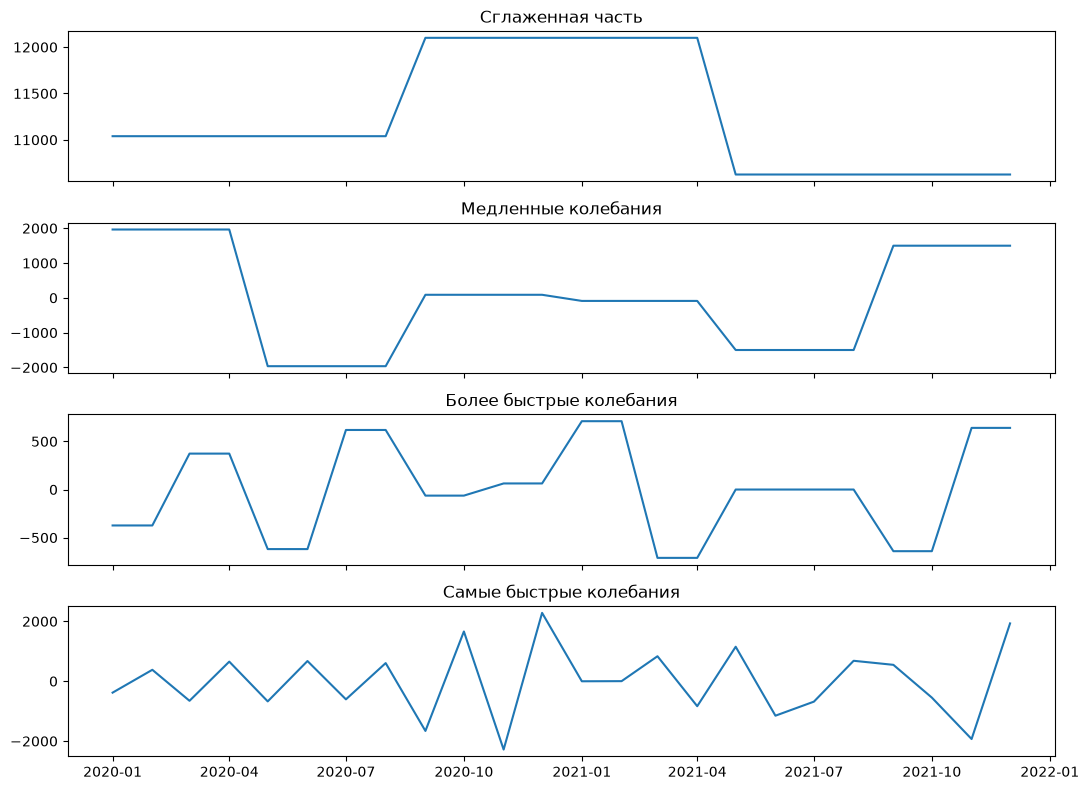

Максимальная разница между исходными продажами и суммой частей 3.637978807091713e-12


In [ ]:
# разделим ряд на сглаженную часть и колебания разной скорости
dwt_coefficients = pywt.wavedec(values, 'db1', level=3, mode='symmetric')

dwt_parts = {}
for i, name in enumerate(['A3', 'D3', 'D2', 'D1']):
    isolated = [np.zeros_like(part) for part in dwt_coefficients]
    isolated[i] = dwt_coefficients[i]
    dwt_parts[name] = pywt.waverec(isolated, 'db1', mode='symmetric')[:len(values)]

dwt_parts = pd.DataFrame(dwt_parts, index=y.index)

titles = {
    'A3': 'Сглаженная часть',
    'D3': 'Медленные колебания',
    'D2': 'Более быстрые колебания',
    'D1': 'Самые быстрые колебания'
}

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, name in zip(axes, dwt_parts):
    ax.plot(y.index, dwt_parts[name])
    ax.set_title(titles[name])

plt.tight_layout()
plt.show()

# сложим части обратно и сравниваем с исходными продажами
print('Максимальная разница между исходными продажами и суммой частей',np.max(abs(dwt_parts.sum(axis=1) - values)))

Сумма частей DWT тоже восстановила ряд с ошибкой округления

Итоги:

- FFT сразу показал цикл в 12 месяцев, но не показал, как он менялся со временем

- Аддитивное разложение подходит если сезонные подъёмы и спады примерно одинаковые по размеру. Если с ростом продаж эти перепады тоже увеличиваются, подходит мультипликативное разложение

- STL лучше подстраивается под изменения ряда. Но у нас всего два года данных, поэтому маленькие остатки ещё не означают, что прогноз будет хорошим

- На Морле видно, какие колебания выделяются в разные месяцы, но у краёв результат может искажаться

## Выбор модели

Еще заюзаю RMSE, чтобы видеть ошибку в единицах продаж

In [ ]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mse = np.mean((y_true - y_pred) ** 2)
    total = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / total if total > 0 else np.nan

    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

results_summary = {}

### Простые прогнозы

Возьму 3 простых прогноза:
1) Во всех будущих месяцах продажи такие же как в последнем месяце train

2) Продажи такие же как в том же месяце год назад

3) Посчитаю средний прирост за месяц на трейне и дальше каждый месяц прибавляю его к последнему значению. Если прирост отрицательный значит продажи снижаются

In [ ]:
# во всех месяцах повторяем последнее известное значение
pred_naive = np.repeat(y_train.iloc[-1], len(y_val))

# берем продажи за те же месяцы прошлого года
pred_seasonal = y_train.iloc[-12:].to_numpy()

# считаем средний прирост за месяц и продолжаем его вперёд
drift = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)
pred_drift = y_train.iloc[-1] + np.arange(1, len(y_val) + 1) * drift

results_summary['Naive'] = calculate_metrics(y_val, pred_naive)
results_summary['SeasonalNaive'] = calculate_metrics(y_val, pred_seasonal)
results_summary['Drift'] = calculate_metrics(y_val, pred_drift)

pd.DataFrame(results_summary).T.rename(index={
    'Naive': 'Последнее значение',
    'SeasonalNaive': 'Как год назад',
    'Drift': 'Средний прирост'
})

,MSE,RMSE,R2
Последнее значение,1.331295e+07,3648.691546,-1.154028
Как год назад,2.458517e+06,1567.965773,0.602213
Средний прирост,1.792658e+07,4233.979679,-1.900512


У «как год назад» R^2=0.60, а ввсе остальные ушли в минус

### ARIMA

Параметры взял так:
1) `d=0` это сами продажи, `d=1` — разница с предыдущим месяцем
2) `(p, q) = (0, 0)`, самый простой вариант, без учёта прошлых значений и ошибок
3) `(1, 0)` учитывает предыдущее значение, `(0, 1)` ошибку предыдущего шага, `(1, 1)` оба варианта вместе
4) `(2, 0)`

P.S. Сделал еще продажи в тысячах, чтобы модели было проще

In [ ]:
# переводим продажи в тысячи
SCALE = 1000

arima_orders = [
    (p, d, q)
    for d in [0, 1]
    for p, q in [(0, 0), (1, 0), (2, 0), (0, 1), (1, 1)]
]

arima_results = []
arima_models = {}

for order in arima_orders:
    # без разности учитываем постоянный уровень, с разностью средний прирост
    trend = 'c' if order[1] == 0 else 't'

    model = ARIMA(y_train / SCALE, order=order, trend=trend)
    model_fit = model.fit(method_kwargs={'maxiter': 500})

    pred = model_fit.forecast(len(y_val)) * SCALE

    arima_results.append({
        'order': order,
        **calculate_metrics(y_val, pred),
        'AIC': model_fit.aic,
        'BIC': model_fit.bic,
        'd': order[1]
    })
    arima_models[order] = model_fit

# сначала показываются модели с меньшей ошибкой
df_arima = pd.DataFrame(arima_results).sort_values('MSE')
df_arima

,order,MSE,RMSE,R2,AIC,BIC,d
4,"(1, 0, 1)",5.626697e+06,2372.065979,0.089603,106.951037,111.663252,0
1,"(1, 0, 0)",5.674767e+06,2382.176920,0.081826,105.194429,108.728590,0
2,"(2, 0, 0)",5.687176e+06,2384.780016,0.079818,106.422929,111.135144,0
3,"(0, 0, 1)",6.135746e+06,2477.043759,0.007240,105.908582,109.442743,0
0,"(0, 0, 0)",6.773718e+06,2602.636708,-0.095984,105.289593,107.645701,0
8,"(0, 1, 1)",7.904820e+06,2811.551153,-0.278996,106.263854,109.670336,1
6,"(1, 1, 0)",9.704953e+06,3115.277296,-0.570256,105.375943,108.782426,1
7,"(2, 1, 0)",1.024309e+07,3200.482670,-0.657327,107.343814,111.885791,1
9,"(1, 1, 1)",1.025725e+07,3202.694179,-0.659618,107.340541,111.882518,1
5,"(0, 1, 0)",1.792634e+07,4233.950863,-1.900472,108.351714,110.622702,1


In [ ]:
best_arima_order = df_arima.iloc[0]['order']
best_arima = arima_models[best_arima_order]
pred_arima = best_arima.forecast(len(y_val)) * SCALE

results_summary['ARIMA'] = calculate_metrics(y_val, pred_arima)
print('best params', best_arima_order)
print('ARIMA', results_summary['ARIMA'])

best params (1, 0, 1)
ARIMA {'MSE': np.float64(5626697.007588208), 'RMSE': np.float64(2372.065978759488), 'R2': np.float64(0.08960334662640934)}


### SARIMAX

Тут вот так:
1) учту продажи год назад или разницу с тем же месяцем прошлого года
2) добавлю акции и праздничный месяц как признаки
3) задам годовые подъёмы и спады через sin/cos

Считаем, что заранее знаем, в какие месяцы будут акции.

In [ ]:
def get_features(data, feature_set):
    # при разности с прошлым годом признак декабря превращается в ноль
    if feature_set == 'promotion':
        columns = ['Promotion']
    else:
        columns = ['Promotion', 'HolidayMonth']

    features = data[columns].astype(float).copy()

    # плавные подъёмы и спады, которые повторяются каждый год
    if feature_set == 'fourier':
        phase = 2 * np.pi * (data.index.month - 1) / 12
        features['sin_12'] = np.sin(phase)
        features['cos_12'] = np.cos(phase)

    return features

seasonal_params = [
    # учитывается тот же месяц год назад, акции и декабрь
    ((1, 0, 0, 12), 'calendar'),
    # берем разницу с тем же месяцем прошлого года и учитываем акции
    ((0, 1, 0, 12), 'promotion'),
    # годовой цикл через sin/cos, тут учитываются акции и декабрь
    ((0, 0, 0, 0), 'fourier'),
    # То же самое, но ещё связь с тем же месяцем год назад
    ((1, 0, 0, 12), 'fourier')
]

In [ ]:
sarimax_results = []
sarimax_models = {}

# переборрррр
for order in [(0, 0, 0), (1, 0, 0), (0, 0, 1)]:
    for seasonal_order, feature_set in seasonal_params:
        X_train = get_features(train, feature_set)
        X_val = get_features(val, feature_set)

        model = SARIMAX(
            y_train / SCALE,
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            trend='c'
        )
        model_fit = model.fit(disp=False, maxiter=500)

        pred = model_fit.forecast(len(y_val), exog=X_val) * SCALE

        sarimax_results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'features': feature_set,
            **calculate_metrics(y_val, pred),
            'AIC': model_fit.aic,
            'BIC': model_fit.bic,
            'D': seasonal_order[1]
        })
        sarimax_models[(order, seasonal_order, feature_set)] = model_fit

df_sarimax = pd.DataFrame(sarimax_results).sort_values('MSE')
df_sarimax

,order,seasonal_order,features,MSE,RMSE,R2,AIC,BIC,D
1,"(0, 0, 0)","(0, 1, 0, 12)",promotion,1.089159e+06,1043.627924,0.823775,34.408858,35.863578,1
5,"(1, 0, 0)","(0, 1, 0, 12)",promotion,1.108827e+06,1053.008646,0.820592,36.017820,37.957447,1
9,"(0, 0, 1)","(0, 1, 0, 12)",promotion,1.144609e+06,1069.864028,0.814803,35.786371,37.725998,1
3,"(0, 0, 0)","(1, 0, 0, 12)",fourier,1.333658e+06,1154.841229,0.784215,76.022144,84.268521,0
7,"(1, 0, 0)","(1, 0, 0, 12)",fourier,1.336063e+06,1155.882073,0.783826,77.981693,87.406124,0
0,"(0, 0, 0)","(1, 0, 0, 12)",calendar,1.336338e+06,1156.000754,0.783781,85.471110,91.361379,0
4,"(1, 0, 0)","(1, 0, 0, 12)",calendar,1.394652e+06,1180.954055,0.774346,84.885057,91.953380,0
11,"(0, 0, 1)","(1, 0, 0, 12)",fourier,1.554150e+06,1246.655436,0.748539,83.670586,93.095016,0
8,"(0, 0, 1)","(1, 0, 0, 12)",calendar,1.572522e+06,1254.002340,0.745567,93.998171,101.066494,0
2,"(0, 0, 0)","(0, 0, 0, 0)",fourier,2.045509e+06,1430.213030,0.669038,81.648618,88.716941,0


In [ ]:
best_sarimax_params = df_sarimax.iloc[0]

best_order = best_sarimax_params['order']
best_seasonal_order = best_sarimax_params['seasonal_order']
best_features = best_sarimax_params['features']

best_sarimax = sarimax_models[(best_order, best_seasonal_order, best_features)]

X_val = get_features(val, best_features)
pred_sarimax = best_sarimax.forecast(len(y_val), exog=X_val) * SCALE
results_summary['SARIMAX'] = calculate_metrics(y_val, pred_sarimax)

print('Лучшие', best_order, best_seasonal_order, best_features)
print('SARIMAX:', results_summary['SARIMAX'])

Лучшие (0, 0, 0) (0, 1, 0, 12) promotion
SARIMAX: {'MSE': np.float64(1089159.2441865813), 'RMSE': np.float64(1043.6279242079436), 'R2': np.float64(0.8237745999898096)}


Лучше всего сработал простой вариант, там где берутся продажи за тот же месяц прошлого года, добавляется средний прирост и учитываются акции

Варианты с sin/cos тоже сработали, но выбранная модель показала результат лучше

### AIC и BIC для ARIMA

In [ ]:
print('ARIMA без разности (d=0)')
print(df_arima[df_arima['d'] == 0][['order', 'AIC', 'BIC']].sort_values('AIC'))

print('\nARIMA с разностью между соседними месяцами (d=1)')
print(df_arima[df_arima['d'] == 1][['order', 'AIC', 'BIC']].sort_values('AIC'))

ARIMA без разности (d=0)
       order         AIC         BIC
1  (1, 0, 0)  105.194429  108.728590
0  (0, 0, 0)  105.289593  107.645701
3  (0, 0, 1)  105.908582  109.442743
2  (2, 0, 0)  106.422929  111.135144
4  (1, 0, 1)  106.951037  111.663252

ARIMA с разностью между соседними месяцами (d=1)
       order         AIC         BIC
6  (1, 1, 0)  105.375943  108.782426
8  (0, 1, 1)  106.263854  109.670336
9  (1, 1, 1)  107.340541  111.882518
7  (2, 1, 0)  107.343814  111.885791
5  (0, 1, 0)  108.351714  110.622702


По AIC лучше `(1, 0, 0)`, по BIC `(0, 0, 0)`. А на val немного лучше `(1, 0, 1)`, где MSE 5.627 млн против 5.675 млн у `(1, 0, 0)`

Возьму `(1, 0, 1)`

### AIC и BIC для SARIMAX

In [ ]:
for D in [0, 1]:
    if D == 0:
        print('SARIMAX без разности с прошлым годом')
    else:
        print('\nSARIMAX с разностью с тем же месяцем прошлого года')

    print(df_sarimax[df_sarimax['D'] == D][
        ['order', 'seasonal_order', 'features', 'AIC', 'BIC']
    ].sort_values('AIC'))

SARIMAX без разности с прошлым годом
        order seasonal_order  features        AIC         BIC
3   (0, 0, 0)  (1, 0, 0, 12)   fourier  76.022144   84.268521
10  (0, 0, 1)   (0, 0, 0, 0)   fourier  76.761470   85.007847
7   (1, 0, 0)  (1, 0, 0, 12)   fourier  77.981693   87.406124
2   (0, 0, 0)   (0, 0, 0, 0)   fourier  81.648618   88.716941
6   (1, 0, 0)   (0, 0, 0, 0)   fourier  82.877233   91.123609
11  (0, 0, 1)  (1, 0, 0, 12)   fourier  83.670586   93.095016
4   (1, 0, 0)  (1, 0, 0, 12)  calendar  84.885057   91.953380
0   (0, 0, 0)  (1, 0, 0, 12)  calendar  85.471110   91.361379
8   (0, 0, 1)  (1, 0, 0, 12)  calendar  93.998171  101.066494

SARIMAX с разностью с тем же месяцем прошлого года
       order seasonal_order   features        AIC        BIC
1  (0, 0, 0)  (0, 1, 0, 12)  promotion  34.408858  35.863578
9  (0, 0, 1)  (0, 1, 0, 12)  promotion  35.786371  37.725998
5  (1, 0, 0)  (0, 1, 0, 12)  promotion  36.017820  37.957447


С разностью с прошлым годом все три показателя выбрали одну и ту же простую модель. Добавление AR и MA ничего не дало

In [ ]:
df_results = pd.DataFrame(results_summary).T
df_results.sort_values('MSE')

,MSE,RMSE,R2
SARIMAX,1.089159e+06,1043.627924,0.823775
SeasonalNaive,2.458517e+06,1567.965773,0.602213
ARIMA,5.626697e+06,2372.065979,0.089603
Naive,1.331295e+07,3648.691546,-1.154028
Drift,1.792658e+07,4233.979679,-1.900512


На val лучше всего SARIMAX с R^2=0.824. У «как год назад» R^2 0.602, у ARIMA всего 0.09

## Срок прогноза

Пусть прогноз будет нормальным если R^2 не ниже 0.5, а MSE не больше, чем у «как год назад»

С выбранными параметрами проверю прогнозы от 1 до 12 месяцев с четырёх разных дат.

In [ ]:
# начало с января, апреля, июля и октября 2022 года
development = df.iloc[:36]
rolling_rows = []

for origin in [24, 27, 30, 33]:
    # прогнозируем до конца 2022 года
    history = development.iloc[:origin]
    future = development.iloc[origin:]

    arima_fit = ARIMA(
        history['SalesAmount'] / SCALE,
        order=best_arima_order,
        trend='c' if best_arima_order[1] == 0 else 't'
    ).fit(method_kwargs={'maxiter': 500})

    X_history = get_features(history, best_features)
    X_future = get_features(future, best_features)

    sarimax_fit = SARIMAX(
        history['SalesAmount'] / SCALE,
        exog=X_history,
        order=best_order,
        seasonal_order=best_seasonal_order,
        trend='c'
    ).fit(disp=False, maxiter=500)

    if not arima_fit.mle_retvals['converged'] or not sarimax_fit.mle_retvals['converged']:
        raise RuntimeError(f'Обучение не сошлось на старте {origin}')

    predictions = {
        'ARIMA': np.asarray(arima_fit.forecast(len(future))) * SCALE,
        'SARIMAX': np.asarray(
            sarimax_fit.forecast(len(future), exog=X_future)
        ) * SCALE,
        'SeasonalNaive': history['SalesAmount'].iloc[-12:].to_numpy()[:len(future)]
    }

    for name, pred in predictions.items():
        for lead, (date, actual, estimate) in enumerate(
            zip(future.index, future['SalesAmount'], pred), start=1
        ):
            rolling_rows.append({
                'model': name,
                'origin': origin,
                'date': date,
                'lead': lead,
                'actual': actual,
                'predicted': estimate
            })

rolling = pd.DataFrame(rolling_rows)

Если проверяем прогноз на 6 месяцев, берём только те случаи где есть данные за все 6 месяцев

In [ ]:
horizon_rows = []

for horizon in range(1, 13):
    # Оставляем только случаи, где есть данные за все нужные месяцы
    block = rolling[
        (rolling['origin'] + horizon <= 36) &
        (rolling['lead'] <= horizon)
    ]

    baseline = block[block['model'] == 'SeasonalNaive']
    baseline_mse = calculate_metrics(baseline['actual'], baseline['predicted'])['MSE']

    for name, group in block.groupby('model'):
        score = calculate_metrics(group['actual'], group['predicted'])

        horizon_rows.append({
            'model': name,
            'horizon': horizon,
            'n_origins': group['origin'].nunique(),
            'n_predictions': len(group),
            **score,
            'acceptable': score['R2'] >= 0.5 and score['MSE'] <= baseline_mse
        })

horizon_scores = pd.DataFrame(horizon_rows)

# берем самый длинный прогноз, который отсечку R2>=0.5
selected_horizons = {}
for name in ['ARIMA', 'SARIMAX']:
    passed = horizon_scores[
        (horizon_scores['model'] == name) &
        horizon_scores['acceptable']
    ]

    if len(passed) > 0:
        selected_horizons[name] = int(passed['horizon'].max())
    else:
        selected_horizons[name] = 0

print('На сколько месяцев прошли проверку', selected_horizons)
horizon_scores[horizon_scores['model'] == 'SARIMAX']

На сколько месяцев прошли проверку {'ARIMA': 0, 'SARIMAX': 12}


,model,horizon,n_origins,n_predictions,MSE,RMSE,R2,acceptable
1,SARIMAX,1,4,4,5.710905e+05,755.705290,0.924226,True
4,SARIMAX,2,4,8,1.142655e+06,1068.950646,0.800861,True
7,SARIMAX,3,4,12,8.578181e+05,926.184691,0.861205,True
10,SARIMAX,4,3,12,9.121756e+05,955.078863,0.832835,True
13,SARIMAX,5,3,15,1.051547e+06,1025.449484,0.783443,True
16,SARIMAX,6,3,18,9.069617e+05,952.345391,0.838163,True
19,SARIMAX,7,2,14,8.909283e+05,943.889997,0.844716,True
22,SARIMAX,8,2,16,1.090490e+06,1044.265351,0.786461,True
25,SARIMAX,9,2,18,9.922233e+05,996.104071,0.822949,True
28,SARIMAX,10,1,10,1.155298e+06,1074.847803,0.806994,True


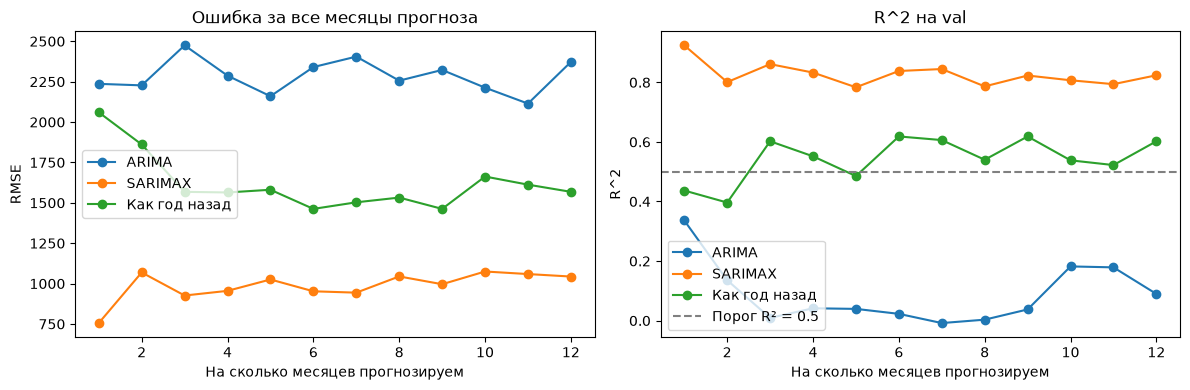

In [ ]:
names = {
    'ARIMA': 'ARIMA',
    'SARIMAX': 'SARIMAX',
    'SeasonalNaive': 'Как год назад'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, label in names.items():
    part = horizon_scores[horizon_scores['model'] == name]
    axes[0].plot(part['horizon'], part['RMSE'], marker='o', label=label)
    axes[1].plot(part['horizon'], part['R2'], marker='o', label=label)

axes[0].set_xlabel('На сколько месяцев прогнозируем')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Ошибка за все месяцы прогноза')

axes[1].set_xlabel('На сколько месяцев прогнозируем')
axes[1].set_ylabel('R^2')
axes[1].set_title('R^2 на val')
axes[1].axhline(0.5, color='gray', linestyle='--', label='Порог R² = 0.5')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

SARIMAX справился с прогнозом до 12 месяцев, а ARIMA нет

Годовой прогноз проверили только с одной даты. Качество считали по всем месяцам вместе, поэтому в отдельных месяцах ошибки могут быть большими

## Проверка прогноза

Учимся дальше на 2020–2022 годах и прогнозируем весь 2023

### Прогноз ARIMA

In [ ]:
arima_model = ARIMA(
    development['SalesAmount'] / SCALE,
    order=best_arima_order,
    trend='c' if best_arima_order[1] == 0 else 't'
)
arima_fit = arima_model.fit(method_kwargs={'maxiter': 500})

arima_forecast = arima_fit.get_forecast(len(y_test))
pred_arima_test = np.asarray(arima_forecast.predicted_mean) * SCALE
ci_arima = np.asarray(arima_forecast.conf_int()) * SCALE

print('Качество прогноза ARIMA', calculate_metrics(y_test, pred_arima_test))

Качество прогноза ARIMA {'MSE': np.float64(4595464.802314869), 'RMSE': np.float64(2143.7035248174757), 'R2': np.float64(0.006354602324966874)}


### Прогноз SARIMAX

In [ ]:
X_train = get_features(development, best_features)
X_test = get_features(test, best_features)

sarimax_model = SARIMAX(
    development['SalesAmount'] / SCALE,
    exog=X_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend='c'
)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=500)

sarimax_forecast = sarimax_fit.get_forecast(len(y_test), exog=X_test)
pred_sarimax_test = np.asarray(sarimax_forecast.predicted_mean) * SCALE
ci_sarimax = np.asarray(sarimax_forecast.conf_int()) * SCALE

print('Качество прогноза SARIMAX', calculate_metrics(y_test, pred_sarimax_test))

Качество прогноза SARIMAX {'MSE': np.float64(606371.0954890301), 'RMSE': np.float64(778.6983340736193), 'R2': np.float64(0.8688885946831021)}


### Графики прогнозов

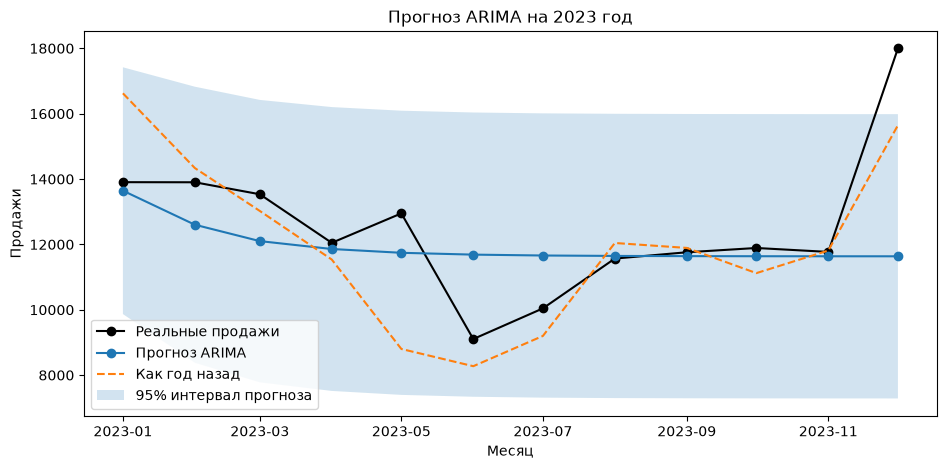

In [ ]:
plt.figure(figsize=(11, 5))

plt.plot(y_test.index, y_test, marker='o', color='black', label='Реальные продажи')
plt.plot(y_test.index, pred_arima_test, marker='o', label='Прогноз ARIMA')
plt.plot(
    y_test.index,
    development['SalesAmount'].iloc[-12:].to_numpy(),
    linestyle='--',
    label='Как год назад'
)
plt.fill_between(
    y_test.index,
    ci_arima[:, 0],
    ci_arima[:, 1],
    alpha=0.2,
    label='95% интервал прогноза'
)

plt.title('Прогноз ARIMA на 2023 год')
plt.xlabel('Месяц')
plt.ylabel('Продажи')
plt.legend()
plt.show()

ARIMA предсказывает почти одинаковые продажи каждый месяц. Спад летом и рост в декабре модель не особо чувствует

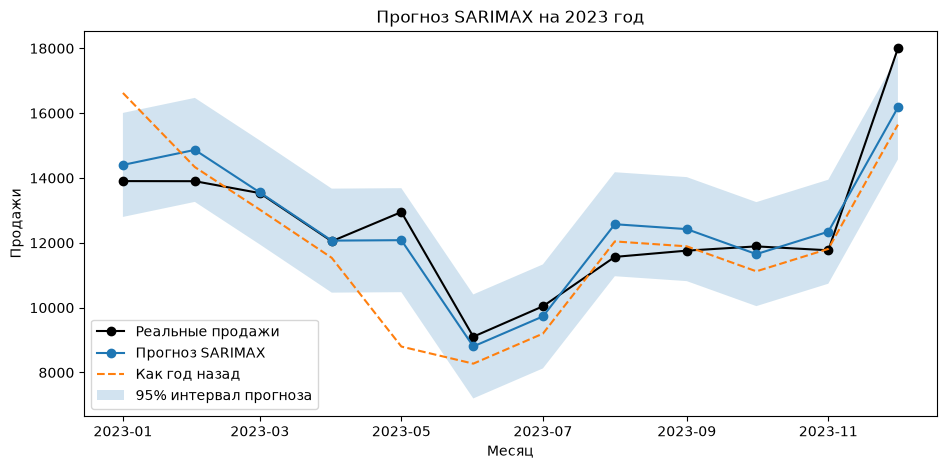

In [ ]:
plt.figure(figsize=(11, 5))

plt.plot(y_test.index, y_test, marker='o', color='black', label='Реальные продажи')
plt.plot(y_test.index, pred_sarimax_test, marker='o', label='Прогноз SARIMAX')
plt.plot(
    y_test.index,
    development['SalesAmount'].iloc[-12:].to_numpy(),
    linestyle='--',
    label='Как год назад'
)
plt.fill_between(
    y_test.index,
    ci_sarimax[:, 0],
    ci_sarimax[:, 1],
    alpha=0.2,
    label='95% интервал прогноза'
)

plt.title('Прогноз SARIMAX на 2023 год')
plt.xlabel('Месяц')
plt.ylabel('Продажи')
plt.legend()
plt.show()

SARIMAX задектекил спад летом и рост зимой, но в декабре реальные продажи оказались выше прогноза

In [ ]:
# сколько реальных значений попало в интервал прогноза
covered = (y_test >= ci_sarimax[:, 0]) & (y_test <= ci_sarimax[:, 1])

print('В 95% интервал прогноза попали продажи за', covered.sum(), 'из', len(y_test), 'месяцев')

В 95% интервал прогноза попали продажи за 11 из 12 месяцев


### Ошибки моделей

In [ ]:
final_models = {'ARIMA': arima_fit, 'SARIMAX': sarimax_fit}

model_degrees = {
    'ARIMA': best_arima_order[0] + best_arima_order[2],
    'SARIMAX': best_order[0] + best_order[2] + best_seasonal_order[0] + best_seasonal_order[2]
}

diagnostic_rows = []
residuals = {}

for family, result in final_models.items():
    burn = max(result.loglikelihood_burn, result.filter_results.nobs_diffuse)
    residual = np.asarray(result.filter_results.standardized_forecasts_error[0, burn:])
    residuals[family] = residual
    model_df = model_degrees[family]

    # Проверяем, связаны ли ошибки между собой
    lb = acorr_ljungbox(residual, lags=[6, 12], model_df=model_df, return_df=True)

    # зависят ли размеры ошибок от предыдущих ошибок
    arch = het_arch(residual, nlags=3, ddof=model_df, result_object=False)

    # Проверяем, похоже ли распределение ошибок на нормальное
    shapiro = stats.shapiro(residual)

    diagnostic_rows.append({
        'model': family,
        'n': len(residual),
        'burn_in': burn,
        'Shapiro p': shapiro.pvalue,
        'Ljung–Box(6) p': lb.loc[6, 'lb_pvalue'],
        'Ljung–Box(12) p': lb.loc[12, 'lb_pvalue'],
        'ARCH(3) p': arch[1],
    })

diagnostics = pd.DataFrame(diagnostic_rows).set_index('model')
diagnostics

,n,burn_in,Shapiro p,Ljung–Box(6) p,Ljung–Box(12) p,ARCH(3) p
model,,,,,,
ARIMA,36,0,0.203008,0.105243,0.008298,0.215698
SARIMAX,24,12,0.523889,0.525143,0.411544,0.937426


Чекнем распределение ошибок, связаны ли между собой и меняется ли их разброс со временем

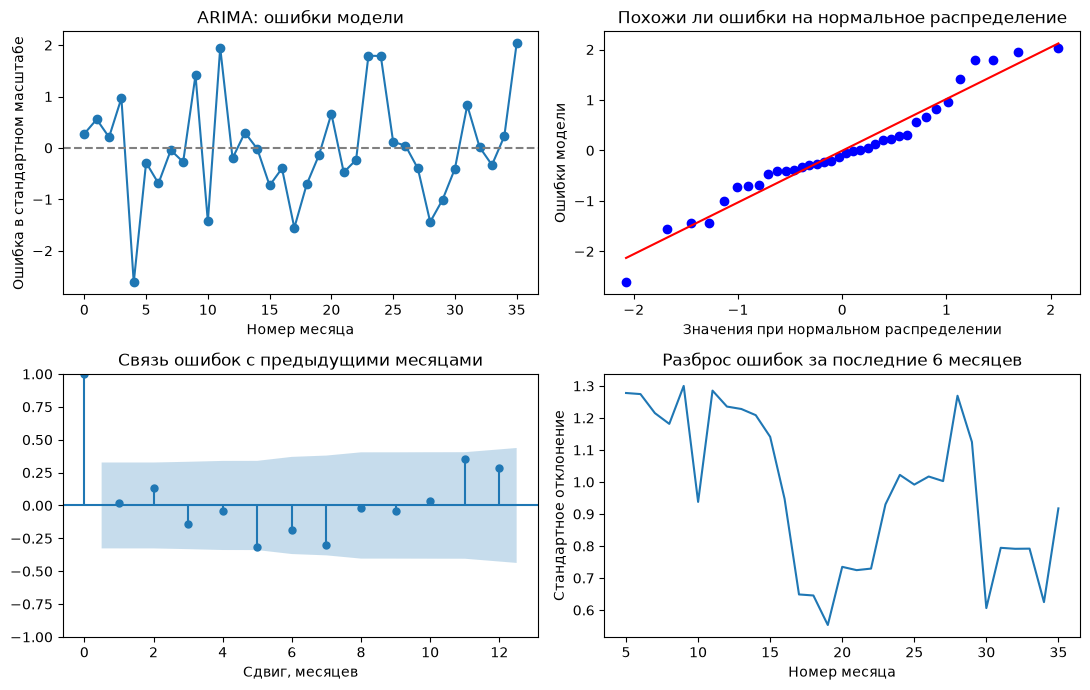

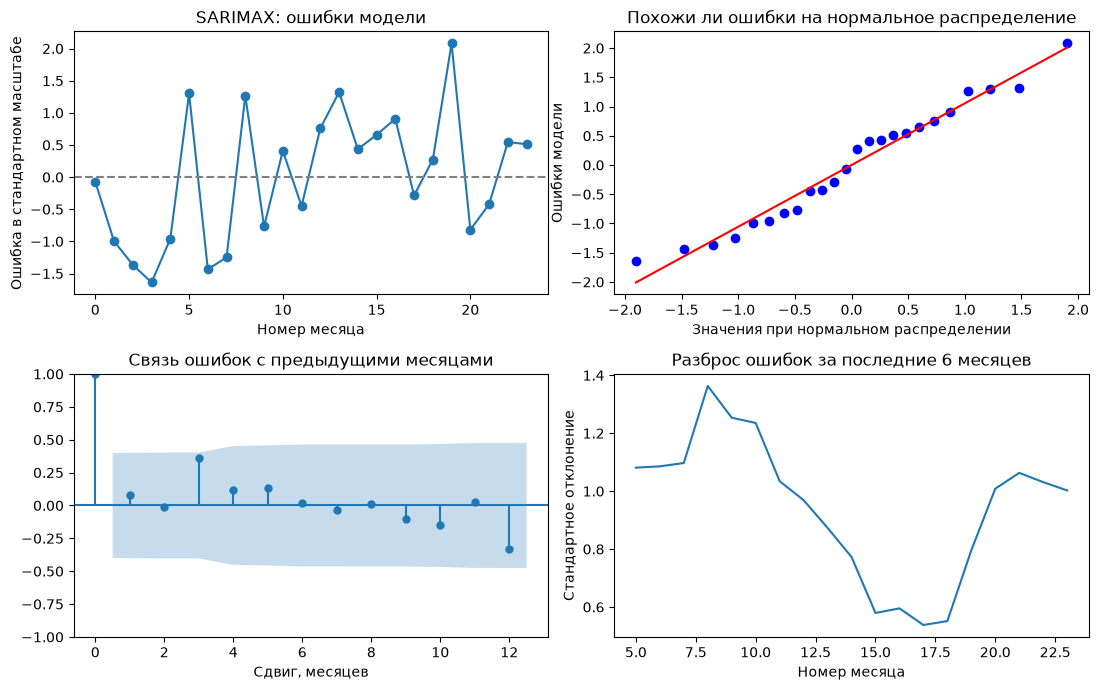

In [ ]:
for family, residual in residuals.items():
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    axes[0, 0].plot(residual, marker='o')
    axes[0, 0].axhline(0, color='gray', linestyle='--')
    axes[0, 0].set_title(f'{family}: ошибки модели')
    axes[0, 0].set_xlabel('Номер месяца')
    axes[0, 0].set_ylabel('Ошибка в стандартном масштабе')

    stats.probplot(residual, dist='norm', plot=axes[0, 1])
    axes[0, 1].set_title('Похожи ли ошибки на нормальное распределение')
    axes[0, 1].set_xlabel('Значения при нормальном распределении')
    axes[0, 1].set_ylabel('Ошибки модели')

    plot_acf(residual, lags=min(12, len(residual) - 1), ax=axes[1, 0])
    axes[1, 0].set_title('Связь ошибок с предыдущими месяцами')
    axes[1, 0].set_xlabel('Сдвиг, месяцев')

    axes[1, 1].plot(pd.Series(residual).rolling(6).std())
    axes[1, 1].set_title('Разброс ошибок за последние 6 месяцев')
    axes[1, 1].set_xlabel('Номер месяца')
    axes[1, 1].set_ylabel('Стандартное отклонение')

    plt.tight_layout()
    plt.show()

У ARIMA ошибки связаны между собой (p=0.008). Модель не выучила часть закономерностей. У SARIMAX тест такой связи не нашёл (p=0.412)

С распределением и разбросом ошибок тесты проблем ничего такого не показали такого

### Рост продаж и акции

In [ ]:
print('Прирост за год', round(sarimax_fit.params['intercept'] * SCALE))
print('Поправка на акцию', round(sarimax_fit.params['Promotion'] * SCALE))

Прирост за год 531
Поправка на акцию 2751


Модель берёт продажи за тот же месяц прошлого года и прибавляет 531. Если сейчас есть акция, а год назад не было, то добавляет ещё 2751. Если наоборот то вычитает 2751

## Итоги

                             MSE         RMSE        R2
Последнее значение  1.427468e+07  3778.184540 -2.086514
Как год назад       2.757115e+06  1660.456338  0.403848
Средний прирост     1.862623e+07  4315.811451 -3.027420
ARIMA               4.595465e+06  2143.703525  0.006355
SARIMAX             6.063711e+05   778.698334  0.868889


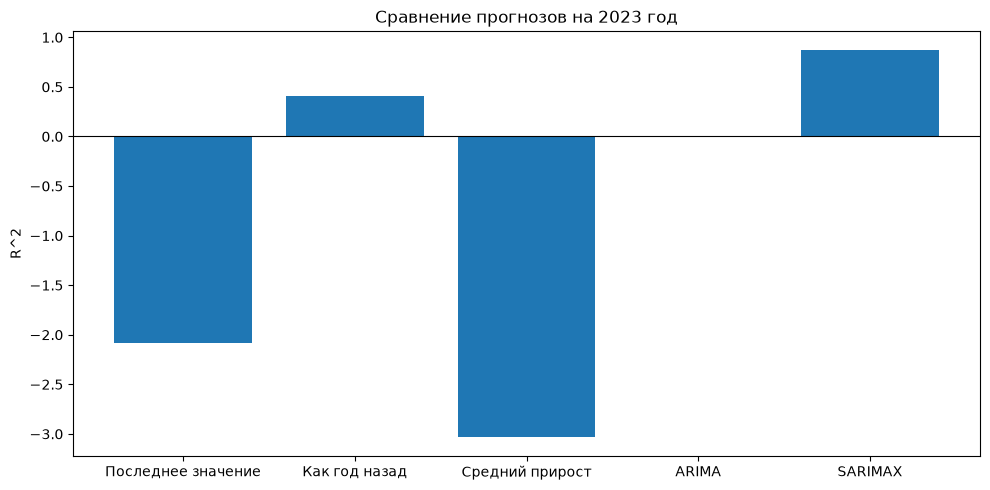

In [ ]:
# прогнозы по данным за 2020–2022 годы
y_development = development['SalesAmount']
test_drift = (y_development.iloc[-1] - y_development.iloc[0]) / (len(y_development) - 1)

test_predictions = {
    'Naive': np.repeat(y_development.iloc[-1], len(y_test)),
    'SeasonalNaive': y_development.iloc[-12:].to_numpy(),
    'Drift': y_development.iloc[-1] + np.arange(1, len(y_test) + 1) * test_drift,
    'ARIMA': pred_arima_test,
    'SARIMAX': pred_sarimax_test
}

# сравнение всех прогнозов с реальными продажами за 2023 год
results_summary = {}
for name, pred in test_predictions.items():
    results_summary[name] = calculate_metrics(y_test, pred)

test_metrics = pd.DataFrame(results_summary).T

comparison = test_metrics.rename(index={
    'Naive': 'Последнее значение',
    'SeasonalNaive': 'Как год назад',
    'Drift': 'Средний прирост'
})
print(comparison)

plt.figure(figsize=(10, 5))
plt.bar(comparison.index, comparison['R2'])
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('R^2')
plt.title('Сравнение прогнозов на 2023 год')
plt.tight_layout()
plt.show()

In [ ]:
final_ic = pd.DataFrame([
    {
        'Модель': name,
        'AIC': model.aic,
        'BIC': model.bic,
        'Число наблюдений': model.nobs_effective
    }
    for name, model in final_models.items()
])

final_ic

,Модель,AIC,BIC,Число наблюдений
0,ARIMA,157.652337,163.986413,36
1,SARIMAX,64.493994,68.028155,24


У SARIMAX для расчёта AIC/BIC осталось 24 наблюдения, у ARIMA 36. Поэтому такое сложное сравнить

Лучше всего показал SARIMAX с MSE=606 371 и R^2=0.869. У «как год назад» R^2=0.404. SARIMAX уменьшил MSE на 78% по сравнению с этим простым прогнозом

ARIMA почти не лучше прогноза средним значением. У вариантов «последнее значение» и «средний прирост» R^2 вообще отрицательный

Выбрал бы SARIMAX, результаты лучше